# dQ/dV

- Run grid search using app.py to find the best parameters to generate ICA curves.
- Use the values in the below code to save the summary and generate plots
- Best parameters are saved here "/results/data/ICA_best_params"

In [2]:
from utils.ica_helper import generate_ica_plots
from pathlib import Path

pdf_path, peaks_path = generate_ica_plots(
    adr_dir=Path("/home/kcv/Desktop/Rate_Capability/results/data/adr_data"),
    output_pdf=Path("/home/kcv/Desktop/Rate_Capability/results/plots/ica_report.pdf"),
    peaks_csv=Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_peak_summary.csv"),
    dv={"CC_DChg": 0.0006210526315789475, "CCCV_Chg": 0.001142105263157894},  # or a single float if you want both the same
    voltage_windows={
        "CC_DChg": (3.15, 3.35),
        "CCCV_Chg": (3.2, 3.5),
    },
    use_savgol_filter=False,
    savgol_window=51,
    savgol_poly=3,
    peaks_per_step={"CC_DChg": 2, "CCCV_Chg": 2},
)

print("PDF saved at:", pdf_path)
print("Peak summary saved at:", peaks_path)


PDF saved at: /home/kcv/Desktop/Rate_Capability/results/plots/ica_report.pdf
Peak summary saved at: /home/kcv/Desktop/Rate_Capability/results/data/ica_peak_summary.csv


# SoH Overlay Plots

In [1]:
from pathlib import Path
from utils.ica_helper import plot_peak_trends

pdf_path = plot_peak_trends(
    peaks_csv=Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_peak_summary.csv"),
    output_pdf=Path("/home/kcv/Desktop/Rate_Capability/results/plots/ica_peak_trends.pdf"),
)
print("Saved:", pdf_path)


Saved: /home/kcv/Desktop/Rate_Capability/results/plots/ica_peak_trends.pdf


In [1]:
from pathlib import Path
from utils.ica_visuals import (
    plot_cell_trajectory_grid,
    plot_cohort_radar,
    plot_peak_health_scorecard,
    plot_interactive_scatter,
    plot_peak_sankey,
)

peaks_csv = Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_peak_summary.csv")
plots_dir = Path("/home/kcv/Desktop/Rate_Capability/results/plots")

plot_cell_trajectory_grid(peaks_csv, plots_dir / "ica_cell_trajectories.pdf")
plot_cohort_radar(peaks_csv, plots_dir / "ica_cohort_radar.pdf")
plot_peak_health_scorecard(peaks_csv, plots_dir / "ica_health_scorecards.pdf")
plot_interactive_scatter(peaks_csv, plots_dir / "ica_degradation_3d.html")
plot_peak_sankey(peaks_csv, plots_dir / "ica_peak_flow.html", step_name="CCCV_Chg")


PosixPath('/home/kcv/Desktop/Rate_Capability/results/plots/ica_peak_flow.html')

In [ ]:
from pathlib import Path
from utils.ica_visuals import evaluate_cluster_counts, cluster_cells_by_peaks, plot_cluster_projection

peaks_csv = Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_peak_summary.csv")
k_eval_csv = Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_cluster_eval.csv")

evaluate_cluster_counts(
    peaks_csv=peaks_csv,
    output_csv=k_eval_csv,
    k_values=range(2, 8)
)
print(k_eval_csv.read_text())



k,silhouette,inertia
2,0.17333434246473584,145.210315443654
3,0.19099593812386462,90.1811089860521
4,0.20193638479482057,68.60402505067498
5,0.21966870060188393,49.90806635169063
6,0.18791616566306601,43.294897836992355
7,0.15339452749604274,38.93799610241353



In [1]:
from pathlib import Path
from utils.ica_visuals import cluster_cells_by_peaks

peaks_csv = Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_peak_summary.csv")
out_csv = Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_cell_clusters.csv")

cluster_cells_by_peaks(peaks_csv, out_csv, n_clusters=5)
print(f"Saved clusters to {out_csv}")


Saved clusters to /home/kcv/Desktop/Rate_Capability/results/data/ica_cell_clusters.csv


Saved PCA cluster plot to /home/kcv/Desktop/Rate_Capability/results/plots/ica_cluster_pca.pdf


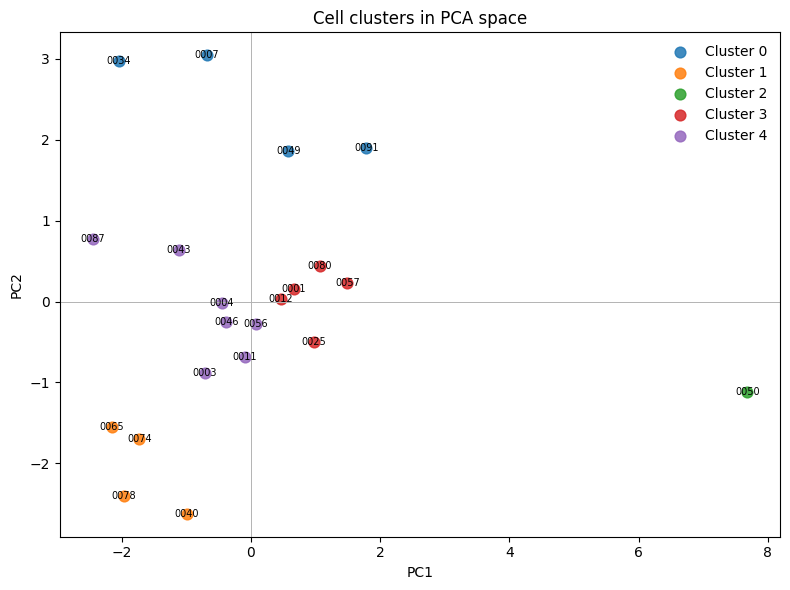

In [2]:
from pathlib import Path
from utils.ica_visuals import plot_cluster_projection

clusters_csv = Path("/home/kcv/Desktop/Rate_Capability/results/data/ica_cell_clusters.csv")
plot_path = Path("/home/kcv/Desktop/Rate_Capability/results/plots/ica_cluster_pca.pdf")

plot_cluster_projection(clusters_csv=clusters_csv, output_pdf=plot_path)
print(f"Saved PCA cluster plot to {plot_path}")


In [3]:
import pandas as pd
clusters = pd.read_csv("/home/kcv/Desktop/Rate_Capability/results/data/ica_cell_clusters.csv")
summary = clusters.groupby("cluster").mean(numeric_only=True)
print(summary)


         peak_dq_dv_P1  peak_dq_dv_P2  peak_dq_dv_P3  voltage_at_peak_P1  \
cluster                                                                    
0          8606.385912    3799.684480     707.489684            3.317442   
1          9095.317867    3248.309973     856.810865            3.311498   
2         12214.055676    6982.344680     908.956428            3.315841   
3          9638.153280    3685.192672     818.175358            3.316026   
4          9247.293024    3463.323492     859.281244            3.317325   

         voltage_at_peak_P2  voltage_at_peak_P3  soh_at_peak_P1  \
cluster                                                           
0                  3.318711            3.286001       63.188723   
1                  3.308952            3.273328       63.741147   
2                  3.334061            3.277951       58.861492   
3                  3.318594            3.279543       62.545890   
4                  3.316919            3.277574       63.710871  

/home/kcv/Desktop/Rate_Capability/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kcv/Desktop/Rate_Capability/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kcv/Desktop/Rate_Capability/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kcv/Desktop/Rate_Capability/.venv/lib/python3.12/site-package

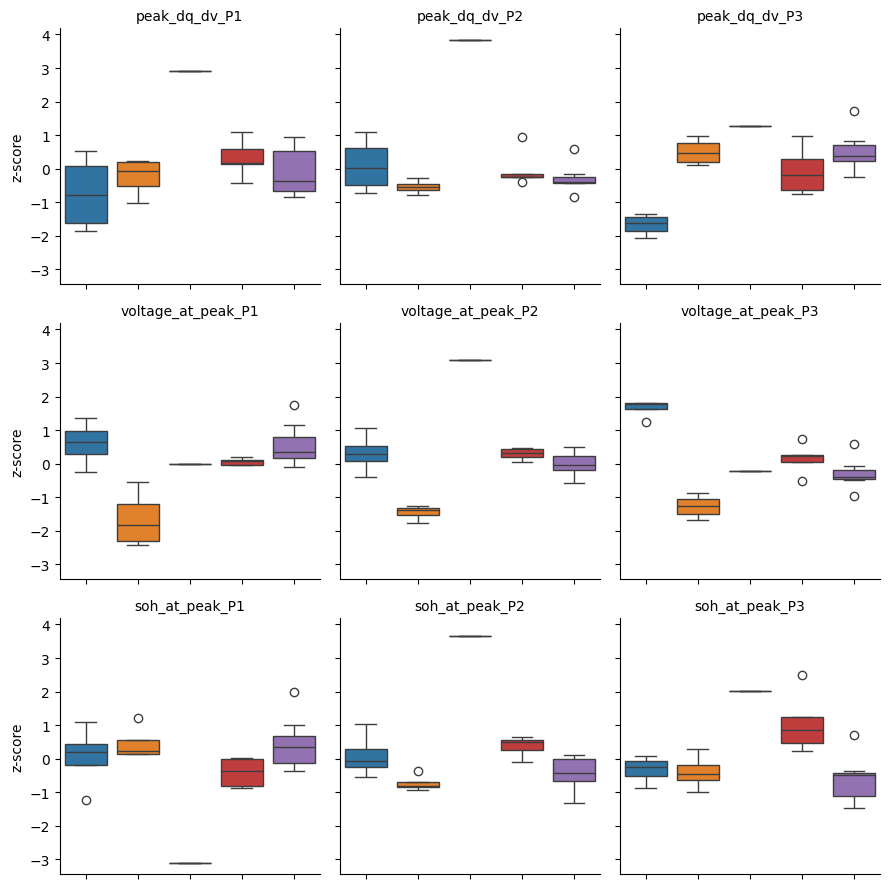

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

clusters = pd.read_csv("/home/kcv/Desktop/Rate_Capability/results/data/ica_cell_clusters.csv")
feature_cols = [c for c in clusters.columns if c not in {"cluster", "cell_id"}]

scaler = StandardScaler()
scaled = clusters.copy()
scaled[feature_cols] = scaler.fit_transform(clusters[feature_cols])
melted = scaled.melt(id_vars=["cluster", "cell_id"], var_name="feature", value_name="value")

g = sns.FacetGrid(melted, col="feature", col_wrap=3, sharey=True, height=3.0)
g.map_dataframe(sns.boxplot, x="cluster", y="value", palette="tab10")
g.set_axis_labels("Cluster", "z-score")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()
